**Задачи**

1. Импортируйте библиотеку `pandas` как `pd`. Загрузите два датасета `user_data` и `logs`. Проверьте размер таблицы, типы переменных, наличие пропущенных значений, описательную статистику.
2. Какой клиент совершил больше всего успешных операций? (`success == True`)
3. С какой платформы осуществляется наибольшее количество успешных операций?
4. Какую платформу предпочитают премиумные клиенты?
5. Визуализируйте распределение возраста клиентов в зависимости от типа клиента (премиум или нет)
6. Постройте график распределения числа успешных операций
7. Визуализируйте число успешных операций, сделанных на платформе computer, в зависимости от возраста, используя `sns.countplot` (x – возраст, y – число успешных операций). Клиенты какого возраста совершили наибольшее количество успешных действий?

## Описание данных

* `user_data`:
    * **client** – идентификатор пользователя
    * **premium** – является ли клиент премиум
    * **age** – возраст
* `logs`:
    * **client** – идентификатор пользователя
    * **success** – результат (успех - 1, нет - 0)
    * **platform** – платформа
    * **time** – время в формате Unix

## Задание 1

Импортируйте библиотеку `pandas` как `pd`. Загрузите два датасета `user_data` и `logs`. Проверьте размер таблицы, типы переменных, посмотрите на описательную статистику. 

Вопрос: Сколько уникальных значений принимает переменная `platform`?

In [1]:
import pandas as pd

users = pd.read_csv("data/3_user_data.csv")
logs = pd.read_csv("data/3_logs.csv")

In [2]:
users.head()

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49


In [3]:
logs.head()

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629


In [4]:
logs.platform.nunique()

3

Посмотреть разбор задания можно по ссылке https://youtu.be/NGv0G_dYo1w

## Задание 2

Какой клиент совершил больше всего успешных операций?

Если несколько пользователей совершили одинаковое число успешных действий, перечислите их идентификаторы (`client`) через запятую и пробел в порядке возрастания. Например: 12, 123, 456

In [5]:
logs.groupby('client').agg(total_sucs = ('success', 'sum')).sort_values('total_sucs', ascending=False).head(10)

,total_sucs
client,
12179,41
36165,41
28719,41
61473,41
92584,41
82563,41
78349,41
52870,41
61468,41


In [6]:
(
   logs
    .groupby('client')
    .agg(total_sucs = ('success', 'sum'))
    .sort_values(['total_sucs', 'client'], ascending=False)
    .reset_index()
)['client'].tolist()

[92584,
 82563,
 78349,
 61473,
 61468,
 52870,
 36165,
 28719,
 12179,
 64064,
 79320,
 99116,
 97999,
 97489,
 96108,
 92743,
 91944,
 90530,
 86496,
 82828,
 82804,
 79139,
 77164,
 75613,
 72479,
 71269,
 70178,
 64746,
 63791,
 59666,
 59357,
 52583,
 51091,
 50065,
 46918,
 44637,
 44413,
 42970,
 39050,
 38742,
 36408,
 32388,
 24071,
 19079,
 19024,
 17938,
 17737,
 17476,
 13204,
 12438,
 8910,
 6888,
 3936,
 2249,
 99993,
 99973,
 99931,
 99927,
 99926,
 99908,
 99903,
 99868,
 99864,
 99754,
 99711,
 99679,
 99668,
 99637,
 99636,
 99631,
 99592,
 99585,
 99538,
 99533,
 99498,
 99464,
 99440,
 99413,
 99409,
 99383,
 99351,
 99308,
 99263,
 99131,
 99114,
 99085,
 99079,
 99056,
 99043,
 98987,
 98964,
 98954,
 98855,
 98854,
 98846,
 98798,
 98717,
 98658,
 98623,
 98509,
 98467,
 98419,
 98336,
 98305,
 98237,
 98161,
 98102,
 98083,
 98047,
 97975,
 97938,
 97934,
 97902,
 97893,
 97879,
 97810,
 97753,
 97751,
 97728,
 97697,
 97607,
 97593,
 97486,
 97443,
 97285,
 972

Посмотреть разбор задания можно по ссылке https://youtu.be/ZEIUsOI-l4g

## Задание 3

С какой платформы осуществляется наибольшее количество успешных операций?

In [7]:
logs[['platform']].value_counts().reset_index()

,platform,count
0,phone,2753
1,computer,1505
2,tablet,242


* [x] Phone
* [ ] Web
* [ ] Tablet
* [ ] Computer

## Задание 4

Какая платформа наиболее популярна среди премиумных клиентов?

In [8]:
full_df = pd.merge(
    logs,
    users,
    on='client',
    how='left'
)

full_df[full_df['premium'] == True].groupby('platform').agg({'client': 'count'})

,client
platform,
computer,150
phone,246
tablet,24


* [ ] Tablet
* [ ] Web
* [ ] Computer
* [x] Phone

## Задание 5

Визуализируйте распределение возраста клиентов в зависимости от типа клиента (премиум или нет), используя библиотеку seaborn с параметрами цвета по умолчанию. Какой график получится в результате?

Используйте датасет, который вы получили на предыдущем шаге

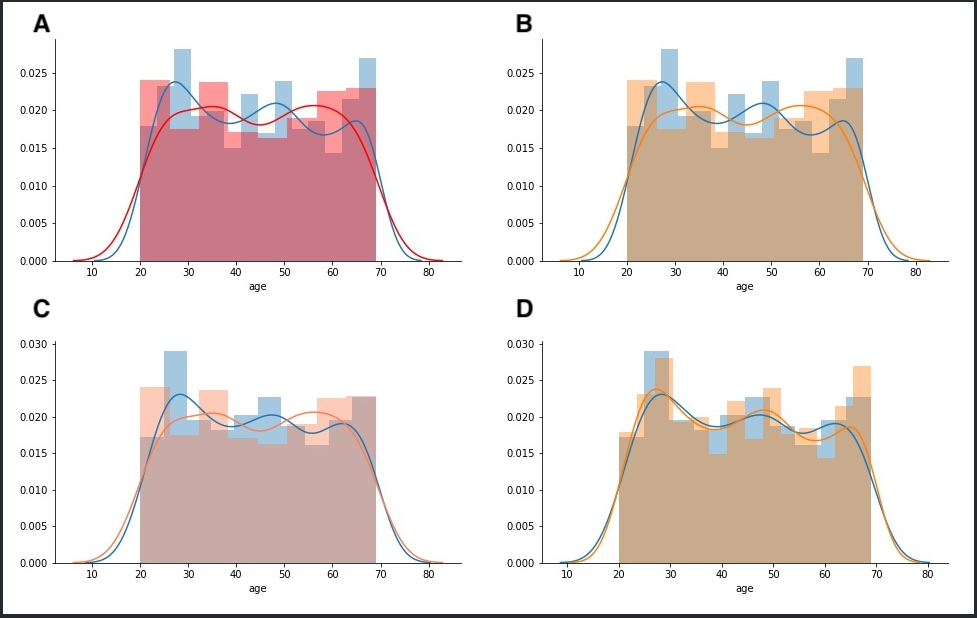

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
users.head()

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49


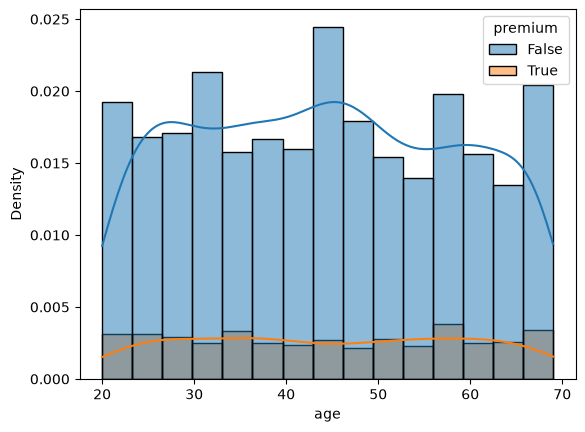

In [16]:
sns.histplot(
    data=users,
    x="age",
    hue="premium",
    kde=True,
    stat="density",
    multiple="layer"
)

plt.show()

* [ ] A
* [x] B
* [ ] C
* [ ] D

## Задание 6

Постройте график распределения числа успешных операций: 
* x – число успешных операций
* y – число клиентов, совершивших столько успешных операций

In [19]:
grp_sucs = full_df[full_df['success'] == True].groupby('client').agg({'success': 'count'}).reset_index()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1556\3282982009.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=grp_sucs['success'], shade=True)


<Axes: xlabel='success', ylabel='Density'>

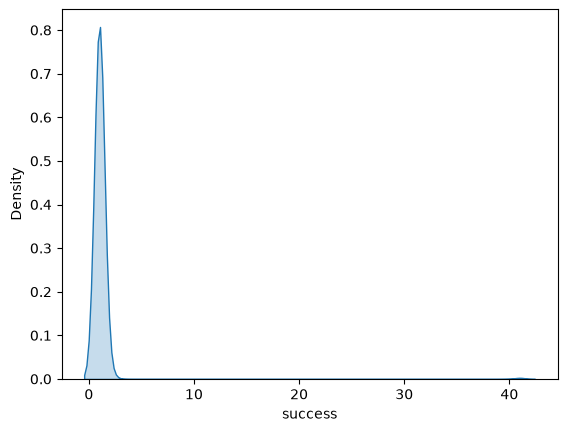

In [20]:
sns.kdeplot(data=grp_sucs['success'], shade=True)

Выберите подходящие утверждения:
* [x] Бóльшая часть наблюдений сосредоточена в левой части графика
* [ ] Все клиенты совершили не более 5 успешных операций
* [x] Несколько клиентов совершили более 40 успешных действий
* [ ] Бóльшая часть наблюдений сосредоточена в правой части графика

## Задание 7

⭐️Задание со звёздочкой!⭐️

Визуализируйте число успешных операций, сделанных на платформе `computer`, в зависимости от возраста, используя `sns.countplot`. По оси x – возраст, y – число успешных операций. Если размер графика получается небольшим, можно добавить `plt.figure(figsize=(12, 8))` в начало соответствующей ячейки. 

Полезные ссылки:
* [sns.countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html) – документация к типу графика
* figsize – про размер графиков

In [22]:
full_df.head()

,client,success,platform,time,premium,age
0,40177,True,phone,1585412212,NaN,NaN
1,61468,True,phone,1585425658,False,25.0
2,35604,False,phone,1585459894,True,65.0
3,9961,True,phone,1585400189,NaN,NaN
4,10931,True,computer,1585468629,False,28.0


In [29]:
cp_ag_secs = (
    full_df[(full_df['success'] == True) & (full_df['platform'] == 'computer')]
    .groupby("age")
    .agg({'client': 'count'})
    .reset_index()
)

In [32]:
cp_ag_secs[cp_ag_secs['client'] == max(cp_ag_secs.client)]

,age,client
8,28.0,49


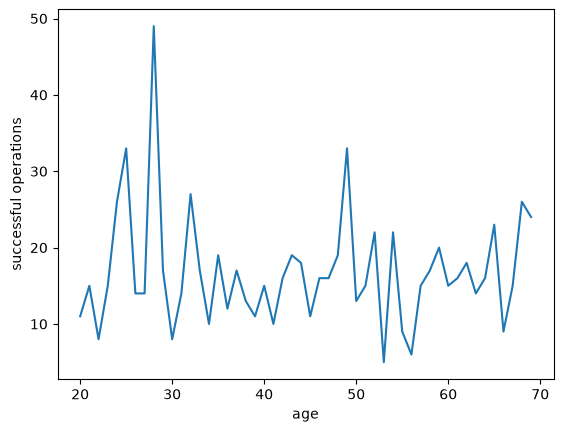

In [31]:
sns.lineplot(
    data=cp_ag_secs,
    x="age",
    y="client"
)

plt.xlabel("age")
plt.ylabel("successful operations")
plt.show()

Посмотреть разбор задания можно по ссылке https://youtu.be/GOgTiZE-X2c